In [4]:
# imports
import torch
print(torch.__version__)
import torchvision
import torchvision.datasets as datasets
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt


2.12.1


In [5]:
transform = transforms.ToTensor()
mnist_trainset = datasets.MNIST(root='./mnist_data', train=True, download=True, transform=transform)
mnist_testset = datasets.MNIST(root='./mnist_data', train=False, download=True, transform=transform)

In [6]:
train_loader = DataLoader(mnist_trainset, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_testset, batch_size=128, shuffle=True)

In [7]:
class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        # turn square pictures into flat vectors 
        self.flatten = nn.Flatten()
        # 784 is the number of pixels and the width of the hidden layer is going to vary
        self.hidden = nn.Linear(784, width)
        # using basic ReLU() which is just max(0, z)
        self.relu = nn.ReLU()
        # 10 is the number of digits / categories so that's how many outputs we will have
        self.output = nn.Linear(width, 10)

    def forward(self, x):
        # turn these into long vectors of pixels
        x = self.flatten(x) 
        # multiply by W_1 matrix and add biases
        z = self.hidden(x)
        # apply the activation functions
        features = self.relu(z)        
        # multiply by W_2 matrix and add biases
        logits = self.output(features)
        # these will be logits
        return features, logits

In [8]:
hidden_layer_width = 128
model = MLP(width=hidden_layer_width)

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [10]:
losses = []
train_accs = []
test_accs = []
all_epochs_features = []

In [11]:
def train_epoch(return_features=False):
    # put the model in train mode
    model.train()
    # used to track loss so you can see if the training is working
    total_loss = 0
    epoch_features = []
    
    # mini-batch SGD
    for x, y in train_loader:
        optimizer.zero_grad()
        features, logits = model(x)
        epoch_features.append(features)
        loss = criterion(logits, y)
        # compute the gradient and store it in .grad attributes of each of the model parameters
        loss.backward()
        # optimizer can access attributes of model parameters and update the parameters
        optimizer.step()
        total_loss += loss.item()
    if return_features:
        return epoch_features, total_loss / len(train_loader)
    return total_loss / len(train_loader)

In [12]:
# evaluate the model's accuracy 
def evaluate_acc(model, loader):
    # put the model in test mode
    model.eval()
    
    correct = 0
    total = 0

    with torch.no_grad():

        for x,y in loader:
            # this calls forward with some wrappers that make it work better i guess
            _, logits = model(x)
            # model predicts the largest value to be the digit
            pred = logits.argmax(dim=1)
            # item makes it a number 
            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total

In [13]:
for epoch in range(100):
    train_acc = evaluate_acc(model, train_loader)
    test_acc = evaluate_acc(model, test_loader)

    # loss = train_epoch()

    epoch_features, loss = train_epoch(return_features=True)
    all_epochs_features.append(epoch_features)

    losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(
        epoch,
        loss,
        train_acc,
        test_acc
    )

0 0.6102870124489513 0.10653333333333333 0.1091
1 0.2968134567427483 0.9075666666666666 0.9117
2 0.24558965393157403 0.9248666666666666 0.9266
3 0.2091010340781354 0.9372333333333334 0.9382
4 0.18112906284614413 0.9463333333333334 0.9467
5 0.15916223325200682 0.9547333333333333 0.9527
6 0.14171278634781775 0.9598333333333333 0.9568
7 0.12766891992740284 0.9635333333333334 0.9612
8 0.11628425551423513 0.9677 0.9643
9 0.10656177037671558 0.96965 0.9658
10 0.09807254664345717 0.9736 0.9683
11 0.09138655046553118 0.9754333333333334 0.9695
12 0.08460723113483076 0.9773333333333334 0.9716
13 0.07924874853303056 0.9785833333333334 0.9724
14 0.07441077679236814 0.9798333333333333 0.9732
15 0.07032441536683454 0.9815333333333334 0.9745
16 0.06626856146749657 0.98225 0.9746
17 0.06292715742945798 0.9833666666666666 0.9761
18 0.05923862300360444 0.98495 0.9766
19 0.056350703486231474 0.9859166666666667 0.9757
20 0.053520072094683076 0.9863 0.9751
21 0.05099535287459141 0.98735 0.9771
22 0.0484314

In [21]:
big_matrices = [torch.cat(epoch_list, dim=0) for epoch_list in all_epochs_features]

In [22]:
# save features and logits before conjugate kernel regression
with torch.no_grad():
    # TEST
    test_features_list = []
    test_logits_original = []
    test_targets_list = []

    for x,y in test_loader:
        features, logits = model(x)
        test_features_list.append(features.cpu())
        test_logits_original.append(logits.cpu())
        test_targets_list.append(y.cpu())
    
    Phi_test = torch.cat(test_features_list, dim=0)
    test_logits_original = torch.cat(test_logits_original, dim=0)
    test_targets = torch.cat(test_targets_list, dim=0)

    # TRAIN
    train_features_list = []
    train_logits_original = []
    train_targets_list = []

    for x, y in train_loader:
        features, logits = model(x)
        train_features_list.append(features.cpu())
        train_logits_original.append(logits.cpu())
        train_targets_list.append(y.cpu())

    Phi_train = torch.cat(train_features_list, dim=0)
    train_logits_original = torch.cat(train_logits_original, dim=0)
    train_targets = torch.cat(train_targets_list, dim=0)


In [23]:
Y_test_onehot = torch.nn.functional.one_hot(test_targets, 10).float().detach().numpy()
Y_train_onehot = torch.nn.functional.one_hot(train_targets, 10).float().detach().numpy()

In [29]:
epoch_index = 49
epoch_1_phi = big_matrices[epoch_index]
M = (epoch_1_phi - epoch_1_phi.mean(dim=0)) / epoch_1_phi.std(dim=0)
M = M.detach().cpu().numpy()

In [26]:
m = hidden_layer_width

In [32]:
N = 60
norm_A = np.zeros(m - 1)
norm_PN_theta = np.zeros(m - 1)
norm_theta_U = np.zeros(m - 1)
norm_A_theta_u = np.zeros(m - 1)
risk = np.zeros(m - 1)

theta_full = np.linalg.lstsq(M, Y_train_onehot, rcond=None)[0]
for i in range(1, hidden_layer_width):
    # breaking up the matrix and vectors
    M_TM = M[:N, :i]
    M_TU = M[:N, i:]
    M_PM = M[N:, :i]
    M_PU = M[N:, i:]
    theta_M = theta_full[:i]
    theta_U = theta_full[i:]
    M_TM_pinv = np.linalg.pinv(M_TM)  
    theta_hat = M_TM_pinv @ Y_train_onehot[:N]
    
    y_hat = M_TM @ theta_hat
    y_test_hat = M[N:, :i] @ theta_hat
    risk[i - 1] = np.mean((np.vstack((y_hat, y_test_hat)) - Y_train_onehot)**2)
    
    A = M_TM_pinv @ M_TU
    norm_A[i - 1] = np.linalg.norm(A, ord=2)
    
    B = M_TM_pinv @ M_TM
    PN = np.eye(i) - B
    if i > N:
        norm_PN_theta[i - 1] = np.linalg.norm(PN@theta_M)
    
    norm_theta_U[i - 1] = np.linalg.norm(theta_U)
    norm_A_theta_u[i - 1] = np.linalg.norm(A @ theta_U)

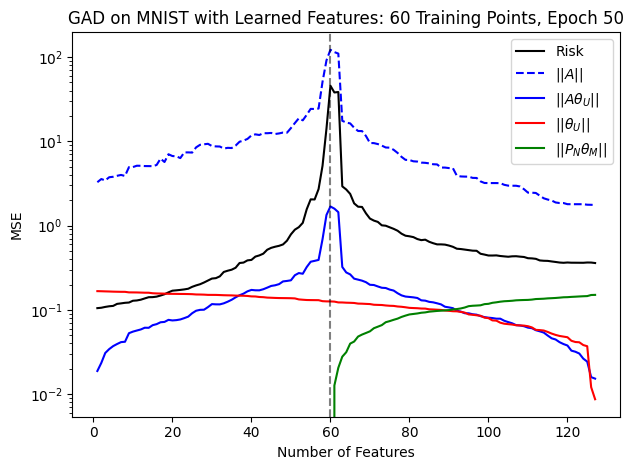

In [33]:
plt.semilogy(np.arange(1, m), risk, label='Risk', color="black")
plt.semilogy(np.arange(1, m), norm_A, label=r"$|| A ||$", color="blue", linestyle='--')
plt.semilogy(np.arange(1, m), norm_A_theta_u, label=r"$|| A \theta_U||$", color="blue")
plt.semilogy(np.arange(1, m), norm_theta_U, label=r"$||\theta_U||$", color="red")
plt.semilogy(np.arange(1, m), norm_PN_theta, label=r"||$P_N \theta_M$||", color="green")

plt.title(f"GAD on MNIST with Learned Features: {N} Training Points, Epoch {epoch_index + 1}")
plt.xlabel("Number of Features")
plt.ylabel("MSE")
plt.axvline([N], color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f'./mnist_plots/GAD_{N}points_epoch{epoch_index}.jpg')
plt.show()

notes to self: 
- I'd like to graph GAD on some of these epoch graphs using the phi matrix as the design, possibly ordering columns by sum of W2 rows? 
- I could try to graph effective rank and/or singular values distribution like joseph did.
- I'd like to experiment with splicing in CK descent to save training time / replicating that result from Pacific Northwest
- I'd like to plot the difference in coefficients of CK best regression solution vs coefficients found by SGD (include bias so it's a fair comparison)
- I could try a CNN on this and see how the GAD looks different / see if the kernel regression thing works better since that kernel is way more appropriate for the task
- I could graph the heatmap of the sorted (blocks by true label) kernel matrix, hopefully seeing the pattern of blocks of dark on the diagnol blocks and sparse/smaller entries elsewhere (or negative? idk)
- add AIC and BIC to GAD plots 
- check notes from last meeting; lots of things you're probs forgetting in there